# Risk-on vs Risk-off Regimes

Financial markets broad regimes that reflect investor behaviour and global liquidity conditions:

- **Risk-on** → investors seek return and take risk  
- **Risk-off** → investors seek safety and reduce risk  

These regimes drive cross-asset correlations, FX carry performance, credit spreads, and equity volatility.



### Economic intuition

Risk-on environments typically occur when:
- growth expectations improve  
- liquidity is abundant  
- central banks are supportive  
- financial stress is low  

Risk-off environments typically occur when:
- recession fears rise  
- financial conditions tighten  
- geopolitical risk increases  
- market volatility spikes  

Carry trades, credit markets and equity markets are strongly tied to these cycles.


### Ex.: change of regime impact on investment strategies

Lets take as an example **carry trade strategies**. These borrow in low-yield currencies and invest in high-yield assets, making them exposed to:

- FX risk  
- credit risk  
- liquidity risk  

Risk-off episodes trigger a **carry unwind**:

1. Investors sell risky assets  
2. Leveraged positions are reduced  
3. Funding currencies are repurchased  
4. High-yield currencies depreciate rapidly  

This feedback loop explains why FX, credit, equities and volatility often move together during stress events.
During risk-off episodes investors deleverage and unwind these positions, producing large and rapid cross-asset moves.


### Cross-asset behaviour

| Indicator | Interpretation |
|---|---|
| USD Index (DXY Broad) | Global USD liquidity and funding stress |
| VIX | Equity market volatility and demand for protection |
| IG OAS | Investment-grade corporate credit risk |
| HY OAS | High-yield corporate credit risk |
| GPR | Geopolitical risk |
| Brent Oil | Global growth and inflation expectations |
| 5Y Breakeven Inflation | Inflation expectations |
| 5Y Real Yield | Real interest rates and financial conditions |


### Typical regime behaviour

| Asset / Indicator | Risk-on | Risk-off |
|---|---|---|
| Global equities | Rising | Falling |
| Credit spreads (IG, HY) | Tightening | Widening |
| VIX | Low | Elevated |
| USD | Weakening | Strengthening |
| JPY / CHF | Weakening | Strengthening |
| EM FX | Appreciating | Depreciating |
| Oil | Rising | Falling |
| Breakeven inflation | Rising | Falling |
| Real yields | Stable / Rising slowly | Falling initially (flight to safety) |



In [1]:
%run setup_macro.py

FedClient initialized: fed_client object
FRED initialized: store object


In [2]:
series = [
    "US10Y",
    "US2Y",
    "VIX",
    "IG_OAS",
    "HY_OAS",
    "BRENT",
    "BREAKEVEN5Y",
    "REAL5Y",
    "EURUSD",
]

df_fred = store.build_panel(series)
df_fred = store.align(df_fred)

df_fred["Curve_Slope"] = df_fred["US10Y"] - df_fred["US2Y"]
df_fred.head()

,US10Y,US2Y,VIX,IG_OAS,HY_OAS,BRENT,BREAKEVEN5Y,REAL5Y,EURUSD,Curve_Slope
1962-01-02,4.060000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,4.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,3.990000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05,4.020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08,4.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
import yfinance as yf
import pandas as pd

raw = yf.download("GC=F", start="2000-01-01", auto_adjust=True)

gold = (
    raw["Close"].squeeze()
    .rename("gold_price")
    .dropna()
)

print(gold.tail())


[*********************100%***********************]  1 of 1 completed

Date
2026-04-29   4545.200195
2026-04-30   4614.700195
2026-05-01   4629.899902
2026-05-04   4519.500000
2026-05-05   4566.700195
Name: gold_price, dtype: float64


In [4]:
df_fred.tail()

,US10Y,US2Y,VIX,IG_OAS,HY_OAS,BRENT,BREAKEVEN5Y,REAL5Y,EURUSD,Curve_Slope
2026-04-28,4.360000,3.840000,17.830000,0.810000,2.850000,113.890000,2.630000,1.340000,1.171500,0.520000
2026-04-29,4.420000,3.920000,18.810000,0.810000,2.820000,113.890000,2.670000,1.380000,1.169500,0.500000
2026-04-30,4.400000,3.880000,16.890000,0.810000,2.830000,113.890000,2.670000,1.350000,1.172900,0.520000
2026-05-01,4.390000,3.880000,16.990000,0.810000,2.770000,113.890000,2.690000,1.330000,1.175500,0.510000
2026-05-04,4.390000,3.880000,18.290000,0.800000,2.780000,113.890000,2.720000,1.330000,1.175500,0.510000


In [7]:
external_store = ExternalStore()
gpr = external_store.get_gpr()
gpr.head()

,GPR
Date,
1960-01-01,109.670000
1960-01-02,133.240000
1960-01-03,56.840000
1960-01-04,149.870000
1960-01-05,93.220000


In [3]:
gold = external_store.get_yfinance("GOLD")
gold.head()

NameError: name 'yf' is not defined

In [12]:
df = df_fred.join(gpr, how="outer").ffill()
df.head()

,US10Y,US2Y,VIX,IG_OAS,HY_OAS,BRENT,BREAKEVEN5Y,REAL5Y,EURUSD,Curve_Slope,GPR
1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.670000
1960-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.240000
1960-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.840000
1960-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149.870000
1960-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.220000


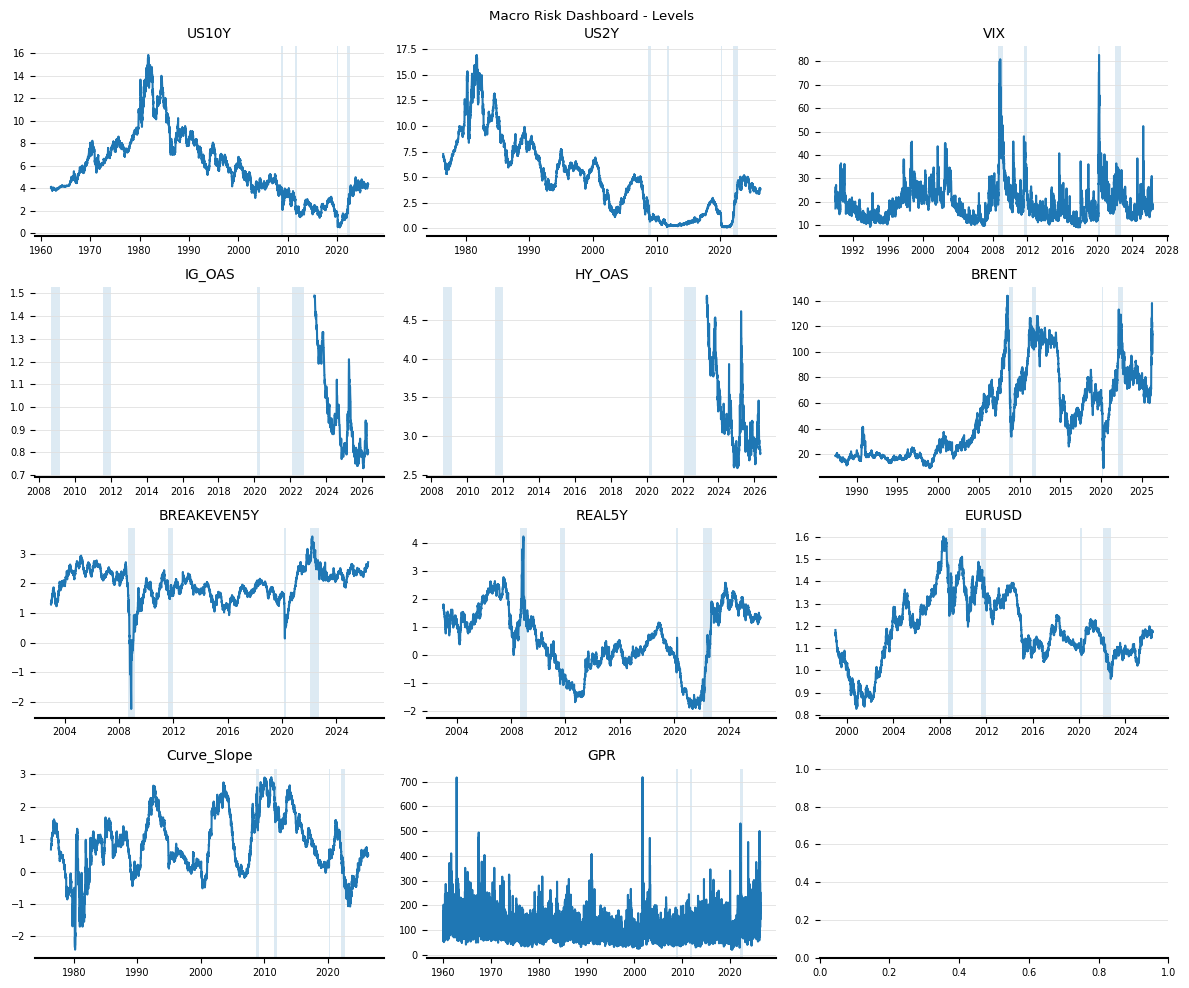

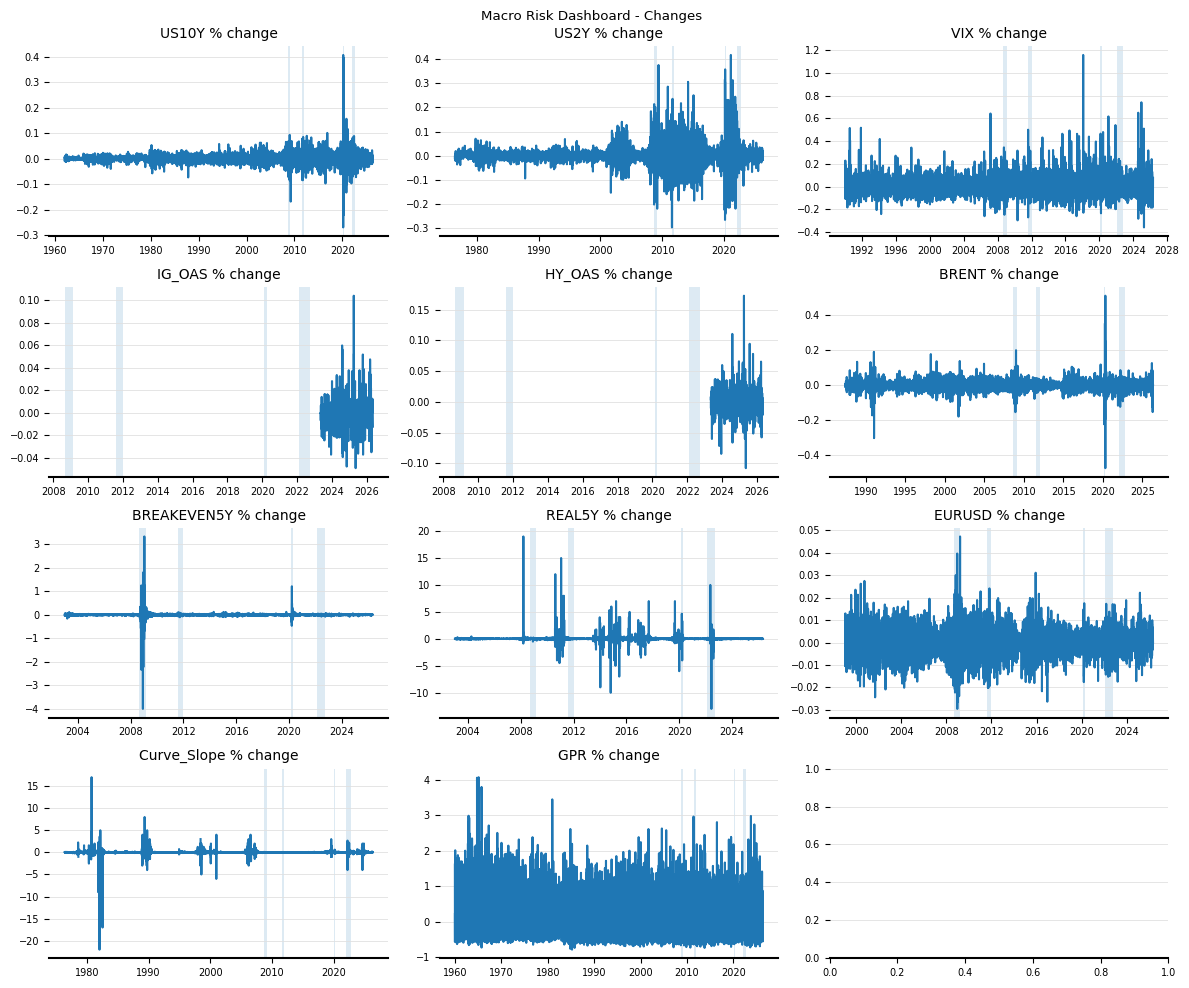

In [14]:


# =========================
# CHANGES
# =========================
df_chg = df.pct_change()

# =========================
# RISK EVENTS
# =========================
events = {
    "GFC": ("2008-09-01","2009-03-01"),
    "Euro": ("2011-08-01","2012-01-01"),
    "COVID": ("2020-02-15","2020-04-15"),
    "2022": ("2022-02-01","2022-10-01"),
}

def shade(ax):
    for _, (s,e) in events.items():
        ax.axvspan(pd.to_datetime(s), pd.to_datetime(e), alpha=0.15)

# =========================
# PLOTS - LEVELS
# =========================
fig, axes = plt.subplots(4,3, figsize=(12,10))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col])
    ax.set_title(col)
    shade(ax)

fig.suptitle("Macro Risk Dashboard - Levels")
plt.tight_layout()
plt.show()

# =========================
# PLOTS - CHANGES
# =========================
fig, axes = plt.subplots(4,3, figsize=(12,10))
axes = axes.flatten()

for ax, col in zip(axes, df_chg.columns):
    ax.plot(df_chg.index, df_chg[col])
    ax.set_title(col + " % change")
    shade(ax)

fig.suptitle("Macro Risk Dashboard - Changes")
plt.tight_layout()
plt.show()